# 06 - MLP Training Core

## Goal
- implement configurable MLP architecture,
- implement `train_one_epoch` with gradient clipping,
- implement `validate_one_epoch`,
- implement full `fit` loop (epochs, early stopping, best checkpoint),
- log metrics to TensorBoard and CSV.


## Mapping to Lab6/7 Points
- **Punkt 3**: implementacja konfigurowalnej architektury `MLPClassifier`.
- **Punkt 4**: implementacja `train_one_epoch(...)` z gradient clipping.
- **Punkt 5**: implementacja `validate_one_epoch(...)`.
- **Punkt 6**: implementacja `fit_model(...)` (epoki, early stopping, best checkpoint, logging CSV/TensorBoard).


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datetime import datetime
from IPython.display import display
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from stylin import InfoDisplayStyler

In [ ]:
styler = InfoDisplayStyler()

In [15]:
DATA_PATH = '../../data/raw/ethusdt_1h.csv'
CLEAN_PATH = '../../data/clean/'
LABELED_PATH = '../../data/labeled/'
PROCESSED_PATH = '../../data/processed/'
CHECKPOINTS_PATH = '../../checkpoints/'
LOGS_PATH = '../../logs/'

SCALED_ARRAYS_FILE = PROCESSED_PATH + 'scaled_arrays.npz'
CLASS_WEIGHTS_FILE = PROCESSED_PATH + 'class_weights.csv'

assert os.path.exists(SCALED_ARRAYS_FILE), 'Missing scaled_arrays.npz. Run notebook 05 first.'
assert os.path.exists(CLASS_WEIGHTS_FILE), 'Missing class_weights.csv. Run notebook 05 first.'

os.makedirs(CHECKPOINTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH + 'tensorboard/', exist_ok=True)


### Loading arrays and class weights

In [16]:
arrays = np.load(SCALED_ARRAYS_FILE)
X_train = arrays['X_train_scaled'].astype(np.float32)
X_val = arrays['X_val_scaled'].astype(np.float32)
X_test = arrays['X_test_scaled'].astype(np.float32)

y_train = arrays['y_train'].astype(np.int64)
y_val = arrays['y_val'].astype(np.int64)
y_test = arrays['y_test'].astype(np.int64)

class_weights_df = pd.read_csv(CLASS_WEIGHTS_FILE)
class_weights = torch.tensor(class_weights_df['class_weight'].to_numpy(dtype=np.float32), dtype=torch.float32)

load_report = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(X_train), len(X_val), len(X_test)],
    'features': [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})
styler.style_me(load_report, title='Loaded arrays report')
styler.style_me(class_weights_df, title='Class weights from notebook 05')


,split,rows,features
0,train,32326,38
1,val,6937,38
2,test,6939,38


,class_id,class_weight
0,0,1.321640
1,1,0.703030
2,2,1.218102


### Reproducibility and training config

In [17]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

TRAINING_CONFIG = {
    'batch_size': 128,
    'epochs': 40,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    'clip_grad_norm': 1.0,
    'early_stopping_patience': 10,
    'monitor_metric': 'f1_macro',
    'monitor_mode': 'max',
    'num_workers': 0,
    'device': DEVICE,
}

MODEL_CONFIG = {
    'input_dim': int(X_train.shape[1]),
    'hidden_dims': [256, 128, 64],
    'num_classes': int(len(np.unique(y_train))),
    'activation': 'gelu',
    'dropout': 0.2,
    'use_batchnorm': True,
}

styler.style_me(pd.DataFrame({'key': list(TRAINING_CONFIG.keys()), 'value': list(TRAINING_CONFIG.values())}), title='Training config')
styler.style_me(pd.DataFrame({'key': list(MODEL_CONFIG.keys()), 'value': list(MODEL_CONFIG.values())}), title='Model config')


,key,value
0,batch_size,128
1,epochs,40
2,learning_rate,0.001000
3,weight_decay,0.000010
4,clip_grad_norm,1.000000
5,early_stopping_patience,10
6,monitor_metric,f1_macro
7,monitor_mode,max
8,num_workers,0
9,device,cpu


,key,value
0,input_dim,38
1,hidden_dims,"[256, 128, 64]"
2,num_classes,3
3,activation,gelu
4,dropout,0.200000
5,use_batchnorm,True


### Dataset and DataLoaders

In [18]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAINING_CONFIG['batch_size'],
    shuffle=True,
    num_workers=TRAINING_CONFIG['num_workers'],
)
val_loader = DataLoader(
    val_dataset,
    batch_size=TRAINING_CONFIG['batch_size'],
    shuffle=False,
    num_workers=TRAINING_CONFIG['num_workers'],
)
test_loader = DataLoader(
    test_dataset,
    batch_size=TRAINING_CONFIG['batch_size'],
    shuffle=False,
    num_workers=TRAINING_CONFIG['num_workers'],
)

styler.style_me(
    pd.DataFrame({
        'loader': ['train', 'val', 'test'],
        'dataset_size': [len(train_dataset), len(val_dataset), len(test_dataset)],
        'num_batches': [len(train_loader), len(val_loader), len(test_loader)],
    }),
    title='DataLoader setup',
)


,loader,dataset_size,num_batches
0,train,32326,253
1,val,6937,55
2,test,6939,55


### Configurable MLP architecture (Task point 3)

In [19]:
def build_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    if name == 'gelu':
        return nn.GELU()
    if name == 'leaky_relu':
        return nn.LeakyReLU(negative_slope=0.1)
    raise ValueError(f'Unsupported activation: {name}')


class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        num_classes: int,
        activation: str = 'gelu',
        dropout: float = 0.2,
        use_batchnorm: bool = True,
    ):
        super().__init__()

        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(build_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


### Train one epoch with gradient clipping (Task point 4)

In [20]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    clip_grad_norm: float | None = None,
) -> dict[str, float]:
    model.train()
    running_loss = 0.0
    num_batches = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

        optimizer.step()

        running_loss += float(loss.item())
        num_batches += 1

    avg_train_loss = running_loss / max(1, num_batches)
    return {'train_loss': avg_train_loss}


### Validation at end of epoch (Task point 5)

In [21]:
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> dict[str, float]:
    model.eval()

    running_loss = 0.0
    num_batches = 0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

        running_loss += float(loss.item())
        num_batches += 1

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    return {
        'val_loss': running_loss / max(1, num_batches),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
    }


### Full training loop (Task point 6)

In [22]:
def _is_improvement(curr: float, best: float, mode: str) -> bool:
    if mode == 'max':
        return curr > best
    if mode == 'min':
        return curr < best
    raise ValueError(f'Unsupported monitor mode: {mode}')


def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
    monitor_metric: str,
    monitor_mode: str,
    early_stopping_patience: int,
    clip_grad_norm: float | None,
    checkpoint_path: str,
    tensorboard_log_dir: str,
    history_csv_path: str,
) -> tuple[pd.DataFrame, dict]:
    model = model.to(device)
    writer = SummaryWriter(log_dir=tensorboard_log_dir)

    best_score = float('-inf') if monitor_mode == 'max' else float('inf')
    best_epoch = -1
    history = []

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            clip_grad_norm=clip_grad_norm,
        )
        val_metrics = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
        )

        row = {
            'epoch': epoch,
            **train_metrics,
            **val_metrics,
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)

        writer.add_scalar('loss/train', row['train_loss'], epoch)
        writer.add_scalar('loss/val', row['val_loss'], epoch)
        writer.add_scalar('metrics/f1_macro', row['f1_macro'], epoch)
        writer.add_scalar('metrics/balanced_accuracy', row['balanced_accuracy'], epoch)
        writer.add_scalar('metrics/accuracy', row['accuracy'], epoch)
        writer.add_scalar('optim/lr', row['lr'], epoch)

        monitored = row[monitor_metric]
        if _is_improvement(monitored, best_score, monitor_mode):
            best_score = monitored
            best_epoch = epoch
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_score': best_score,
                    'monitor_metric': monitor_metric,
                    'model_config': MODEL_CONFIG,
                    'training_config': TRAINING_CONFIG,
                },
                checkpoint_path,
            )

        if epoch - best_epoch >= early_stopping_patience:
            break

    writer.close()

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_csv_path, index=False)

    summary = {
        'best_epoch': int(best_epoch),
        'best_score': float(best_score),
        'monitor_metric': monitor_metric,
        'epochs_ran': int(len(history_df)),
        'checkpoint_path': checkpoint_path,
        'tensorboard_log_dir': tensorboard_log_dir,
        'history_csv_path': history_csv_path,
    }
    return history_df, summary


### Run baseline training

In [23]:
device = torch.device(TRAINING_CONFIG['device'])

model = MLPClassifier(
    input_dim=MODEL_CONFIG['input_dim'],
    hidden_dims=MODEL_CONFIG['hidden_dims'],
    num_classes=MODEL_CONFIG['num_classes'],
    activation=MODEL_CONFIG['activation'],
    dropout=MODEL_CONFIG['dropout'],
    use_batchnorm=MODEL_CONFIG['use_batchnorm'],
)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAINING_CONFIG['learning_rate'],
    weight_decay=TRAINING_CONFIG['weight_decay'],
)

run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
checkpoint_path = CHECKPOINTS_PATH + f'baseline_mlp_{run_id}.pt'
history_csv_path = LOGS_PATH + f'training_history_baseline_{run_id}.csv'
tensorboard_log_dir = LOGS_PATH + f'tensorboard/baseline_{run_id}'

history_df, fit_summary = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=TRAINING_CONFIG['epochs'],
    monitor_metric=TRAINING_CONFIG['monitor_metric'],
    monitor_mode=TRAINING_CONFIG['monitor_mode'],
    early_stopping_patience=TRAINING_CONFIG['early_stopping_patience'],
    clip_grad_norm=TRAINING_CONFIG['clip_grad_norm'],
    checkpoint_path=checkpoint_path,
    tensorboard_log_dir=tensorboard_log_dir,
    history_csv_path=history_csv_path,
)

styler.style_me(pd.DataFrame([fit_summary]), title='Fit summary')
styler.style_me(history_df.tail(10), title='Training history (last 10 epochs)')


,best_epoch,best_score,monitor_metric,epochs_ran,checkpoint_path,tensorboard_log_dir,history_csv_path
0,3,0.376223,f1_macro,13,../../checkpoints/baseline_mlp_20260502_154542.pt,../../logs/tensorboard/baseline_20260502_154542,../../logs/training_history_baseline_20260502_154542.csv


,epoch,train_loss,val_loss,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,lr
3,4,1.021587,1.083395,0.372639,0.389472,0.336460,0.418655,0.389472,0.001000
4,5,1.016545,1.082601,0.368171,0.397620,0.364984,0.433351,0.397620,0.001000
5,6,1.011639,1.084999,0.377108,0.401148,0.369528,0.430618,0.401148,0.001000
6,7,1.004961,1.082949,0.374225,0.397766,0.366686,0.429219,0.397766,0.001000
7,8,1.000129,1.086863,0.366153,0.387777,0.359275,0.419548,0.387777,0.001000
8,9,0.995641,1.094036,0.361684,0.387667,0.355985,0.421862,0.387667,0.001000
9,10,0.990985,1.087112,0.364567,0.386814,0.364357,0.419565,0.386814,0.001000
10,11,0.987016,1.094207,0.359954,0.385037,0.354916,0.421679,0.385037,0.001000
11,12,0.981206,1.098860,0.362260,0.390610,0.359683,0.427810,0.390610,0.001000
12,13,0.975034,1.102733,0.370189,0.392923,0.363276,0.423076,0.392923,0.001000


### Plot training curves and final validation summary

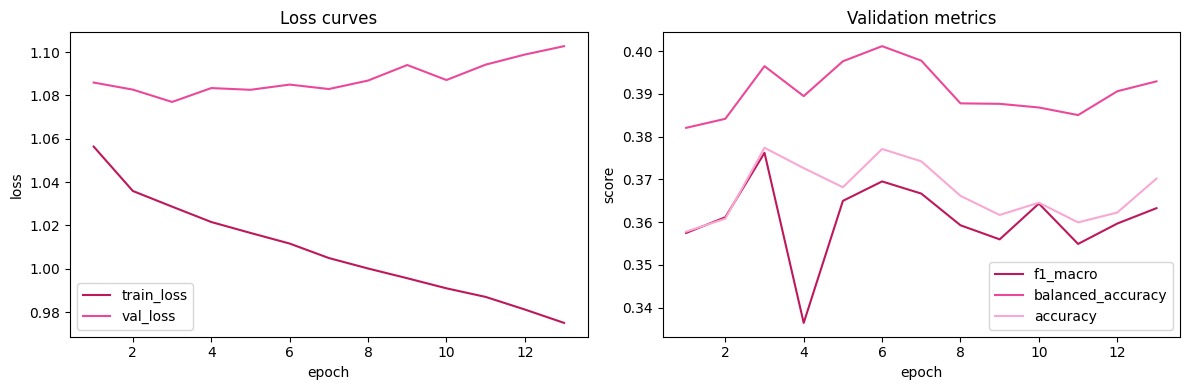

,epoch,train_loss,val_loss,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,lr
2,3,1.028689,1.076990,0.377397,0.396473,0.376223,0.424666,0.396473,0.001000


In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='train_loss', color='#be185d')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val_loss', color='#ec4899')
plt.title('Loss curves')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['f1_macro'], label='f1_macro', color='#be185d')
plt.plot(history_df['epoch'], history_df['balanced_accuracy'], label='balanced_accuracy', color='#ec4899')
plt.plot(history_df['epoch'], history_df['accuracy'], label='accuracy', color='#f9a8d4')
plt.title('Validation metrics')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend()

plt.tight_layout()
plt.show()

best_epoch = int(fit_summary['best_epoch'])
best_row = history_df.loc[history_df['epoch'] == best_epoch].copy()
styler.style_me(best_row, title='Best epoch metrics')
